# Librerías


In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score

# Datos

In [2]:
df = pd.read_csv('datos.csv')

In [3]:
df.head()

,Lote,Semana_prod,Peso_gr,Muertos,Descartes,Iniciador_bolsas,Terminador_bolsas
0,1,1,118,84,0,42,0
1,1,2,198,38,0,85,0
2,1,3,439,35,0,106,0
3,1,4,746,18,0,59,55
4,1,5,1101,21,0,0,172


# Objetivo del modelo


El objetivo principal es **predecir el peso promedio semanal del lote (`Peso_gr`)** a partir de la información productiva disponible hasta esa semana.

En términos de negocio, la pregunta es: **si conozco la semana de producción, la mortalidad acumulada, los descartes, las aves vivas y el peso de la semana anterior, cuánto debería pesar el lote esta semana?**

Este objetivo ayuda a anticipar si un lote viene dentro de lo esperado, detectar desvíos de crecimiento y planificar decisiones de manejo, alimento y fecha probable de salida. Además del modelo principal de peso, el notebook incluye modelos auxiliares para estimar consumo de alimento iniciador y terminador en bolsas.


# Variables usadas


Para el modelo principal se usa como variable objetivo:

- **`Peso_gr`**: peso promedio del lote en gramos para cada semana.

Variables predictoras del modelo de peso:

- **`Semana_prod`**: semana productiva. Captura la etapa de crecimiento del pollo.
- **`Muertos_acum`**: mortalidad acumulada hasta la semana. Resume el impacto sanitario/productivo del lote.
- **`Descartes_acum`**: descartes acumulados. Ayuda a medir pérdidas por calidad o condición de aves.
- **`Aves_vivas`**: aves estimadas en producción. Se calcula restando muertos y descartes al stock inicial.
- **`Peso_anterior`**: peso de la semana previa. Es la referencia más fuerte para proyectar el crecimiento siguiente.
- **`Dias`**: días acumulados de producción, calculados como semana por 7.

El número de **`Lote`** no se usa como predictor directo para evitar que el modelo memorice un lote específico. Se utiliza para ordenar los datos, calcular acumulados y comparar resultados por lote.


# Tipo de modelo


Se utiliza **Machine Learning supervisado de regresión**, con **Random Forest Regressor**.

Es supervisado porque el modelo aprende desde lotes históricos donde ya conocemos el resultado real. Es de regresión porque la salida esperada es un número continuo: gramos de peso o bolsas de alimento.

Random Forest combina muchos árboles de decisión. En vez de depender de una sola regla, promedia muchas reglas aprendidas desde los datos históricos. Esto suele funcionar bien cuando hay relaciones no lineales, como el crecimiento semanal del pollo, donde influyen edad, peso previo, mortalidad y manejo.


In [4]:
# Ordenar por lote y semana
df = df.sort_values(['Lote', 'Semana_prod'])

# Mortalidad acumulada por lote
df['Muertos_acum'] = df.groupby('Lote')['Muertos'].cumsum()

# Descartes acumulados
df['Descartes_acum'] = df.groupby('Lote')['Descartes'].cumsum()

# Aves vivas (asumiendo 4200 iniciales)
# Usaremos 4200 como constante para todos los lotes (ajustar si es diferente)
aves_iniciales = 4200
df['Aves_vivas'] = aves_iniciales - df['Muertos_acum'] - df['Descartes_acum']

# Peso anterior (lag 1)
df['Peso_anterior'] = df.groupby('Lote')['Peso_gr'].shift(1)

# Consumo iniciador anterior
df['Iniciador_anterior'] = df.groupby('Lote')['Iniciador_bolsas'].shift(1)

# Consumo terminador anterior
df['Terminador_anterior'] = df.groupby('Lote')['Terminador_bolsas'].shift(1)

# Días de producción: usamos una variable 'días' que acumule 7 por semana
df['Dias'] = df['Semana_prod'] * 7

# Eliminar filas sin peso anterior (primera semana de cada lote)
df_modelo = df.dropna(subset=['Peso_anterior']).copy()


# Modelo principal: prediccion de peso semanal


In [5]:
# Variables predictoras del modelo principal
features_peso = ['Semana_prod', 'Muertos_acum', 'Descartes_acum', 'Aves_vivas', 'Peso_anterior', 'Dias']
X_peso = df_modelo[features_peso]
y_peso = df_modelo['Peso_gr']

# Entrenamiento del modelo
rf_peso = RandomForestRegressor(n_estimators=100, random_state=42)
rf_peso.fit(X_peso, y_peso)

# Evaluación dentro de la muestra histórica
pred_peso = rf_peso.predict(X_peso)
df_modelo['Peso_pred'] = pred_peso
df_modelo['Error_gr'] = df_modelo['Peso_gr'] - df_modelo['Peso_pred']

mae_peso = mean_absolute_error(y_peso, pred_peso)
rmse_peso = np.sqrt(mean_squared_error(y_peso, pred_peso))
r2_peso = r2_score(y_peso, pred_peso)

print(f"MAE peso: {mae_peso:.2f} g")
print(f"RMSE peso: {rmse_peso:.2f} g")
print(f"R2 peso: {r2_peso:.3f}")


MAE peso: 62.34 g
RMSE peso: 87.59 g
R2 peso: 0.996


**Lectura de resultados del modelo de peso**

- **MAE**: indica el error promedio en gramos. Si el MAE es bajo, el modelo se equivoca poco en una semana típica.
- **RMSE**: también mide error, pero castiga más los errores grandes. Sirve para ver si hay semanas donde el modelo se aleja demasiado.
- **R2**: mide qué tan bien el modelo reproduce la variación observada en los pesos históricos. Valores cercanos a 1 indican mejor ajuste.

Estos resultados deben interpretarse como una primera validación sobre los datos disponibles. Como hay pocos lotes históricos, el modelo puede verse muy preciso dentro de la muestra, pero conviene validarlo con nuevos lotes antes de usarlo como única referencia de decisión.


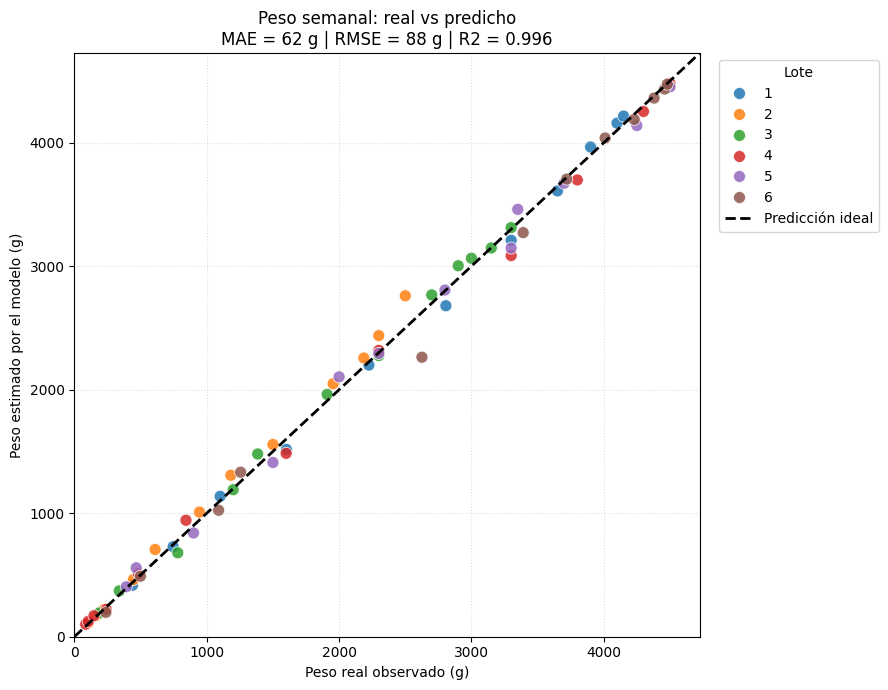

In [6]:
plt.figure(figsize=(9, 7))

sns.scatterplot(
    data=df_modelo,
    x='Peso_gr',
    y='Peso_pred',
    hue='Lote',
    palette='tab10',
    s=75,
    alpha=0.85,
    edgecolor='white',
    linewidth=0.6
)

limite_max = max(df_modelo['Peso_gr'].max(), df_modelo['Peso_pred'].max()) * 1.05
plt.plot([0, limite_max], [0, limite_max], color='black', linestyle='--', linewidth=2, label='Predicción ideal')

plt.xlim(0, limite_max)
plt.ylim(0, limite_max)
plt.xlabel('Peso real observado (g)')
plt.ylabel('Peso estimado por el modelo (g)')
plt.title(f'Peso semanal: real vs predicho\nMAE = {mae_peso:.0f} g | RMSE = {rmse_peso:.0f} g | R2 = {r2_peso:.3f}')
plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1), title='Lote')
plt.grid(True, linestyle=':', alpha=0.4)
plt.tight_layout()
plt.show()


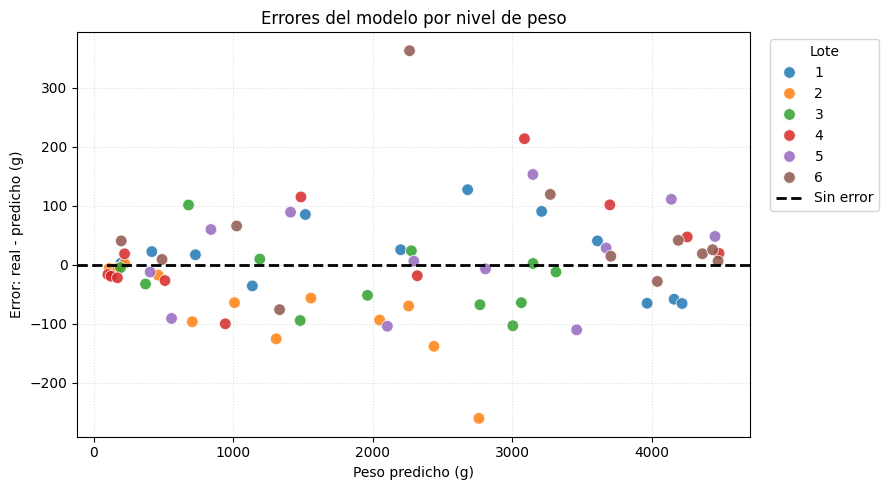

In [7]:
plt.figure(figsize=(9, 5))

sns.scatterplot(
    data=df_modelo,
    x='Peso_pred',
    y='Error_gr',
    hue='Lote',
    palette='tab10',
    s=70,
    alpha=0.85,
    edgecolor='white',
    linewidth=0.6
)

plt.axhline(y=0, color='black', linestyle='--', linewidth=2, label='Sin error')
plt.xlabel('Peso predicho (g)')
plt.ylabel('Error: real - predicho (g)')
plt.title('Errores del modelo por nivel de peso')
plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1), title='Lote')
plt.grid(True, linestyle=':', alpha=0.4)
plt.tight_layout()
plt.show()


**Interpretación de los gráficos de peso**

En el gráfico **real vs predicho**, cada punto representa una semana de un lote. La línea punteada marca la predicción perfecta: cuanto más cerca están los puntos de esa línea, mejor está estimando el modelo.

El gráfico de **errores** muestra cuánto se desvió la predicción. Valores cerca de cero indican buen ajuste. Si aparecen errores muy altos o muy bajos en determinadas semanas, esas semanas deberían revisarse porque pueden indicar cambios de manejo, sanidad, clima, alimento o registros atípicos.


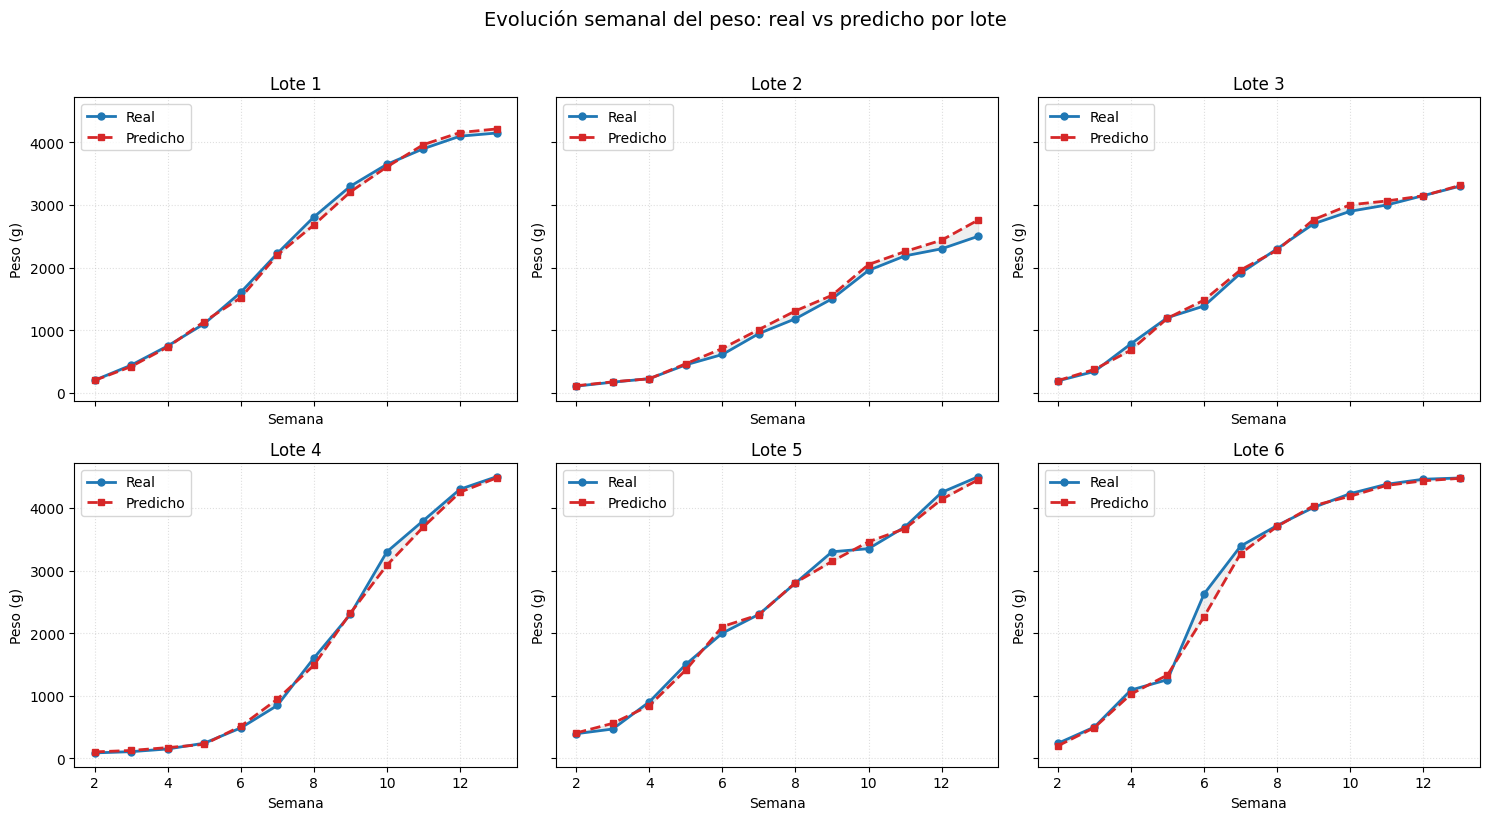

In [8]:
lotes = sorted(df_modelo['Lote'].unique())
n_lotes = len(lotes)
ncols = 3
nrows = (n_lotes + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4 * nrows), sharex=True, sharey=True)
axes = np.array(axes).reshape(-1)

for i, lote in enumerate(lotes):
    subset = df_modelo[df_modelo['Lote'] == lote]
    ax = axes[i]
    ax.plot(subset['Semana_prod'], subset['Peso_gr'], 'o-', color='#1f77b4', linewidth=2, markersize=5, label='Real')
    ax.plot(subset['Semana_prod'], subset['Peso_pred'], 's--', color='#d62728', linewidth=2, markersize=5, label='Predicho')
    ax.fill_between(subset['Semana_prod'], subset['Peso_gr'], subset['Peso_pred'], color='gray', alpha=0.12)
    ax.set_title(f'Lote {lote}')
    ax.set_xlabel('Semana')
    ax.set_ylabel('Peso (g)')
    ax.grid(True, linestyle=':', alpha=0.4)
    ax.legend(loc='upper left')

for j in range(len(lotes), len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Evolución semanal del peso: real vs predicho por lote', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


**Interpretación de la evolución semanal del peso por lote (real vs. predicho)**

- **Qué representa:** Este gráfico permite analizar el desempeño individual de cada lote histórico de manera secuencial a lo largo de las semanas de producción. La línea azul con círculos (`Real`) indica el peso real observado, mientras que la línea roja discontinua con cuadrados (`Predicho`) muestra la estimación calculada por el modelo. El área sombreada en gris resalta la magnitud del error o diferencia entre el valor real y la predicción en cada semana.
- **Cómo interpretarlo:**
  - **Líneas superpuestas o muy cercanas (sombreado mínimo):** El modelo predice con alta precisión el crecimiento de ese lote, logrando capturar correctamente su tendencia y velocidad de ganancia de peso.
  - **Separación entre líneas (sombreado amplio):** Señala desviaciones en las que el lote real creció por encima o por debajo de lo esperado. Estas diferencias permiten identificar retrospectivamente semanas con anomalías de manejo, cambios repentinos de alimento, densidad excesiva de aves, problemas de salud o factores ambientales (como estrés térmico) que afectaron el rendimiento habitual.


# Modelos auxiliares: consumo de iniciador y terminador

Además del peso, se entrenan dos modelos de regresión para estimar consumo de alimento:

- **Iniciador_bolsas**: se entrena solo con semanas donde hubo consumo de iniciador.
- **Terminador_bolsas**: se entrena solo con semanas donde hubo consumo de terminador.

Estos modelos usan semana, peso, mortalidad acumulada y aves vivas. La idea es estimar cuántas bolsas podrían requerirse según el estado productivo del lote. Como el consumo también depende de disponibilidad, fórmula, ambiente y manejo, estas predicciones deben tomarse como una guía operativa, no como una orden automática de compra.


In [9]:
# Iniciador: semanas donde se registra consumo de alimento iniciador
features_cons = ['Semana_prod', 'Peso_gr', 'Muertos_acum', 'Aves_vivas']

df_iniciador = df_modelo[df_modelo['Iniciador_bolsas'] > 0].copy()
X_ini = df_iniciador[features_cons]
y_ini = df_iniciador['Iniciador_bolsas']
rf_ini = RandomForestRegressor(n_estimators=100, random_state=42)
rf_ini.fit(X_ini, y_ini)

# Terminador: semanas donde se registra consumo de alimento terminador
df_terminador = df_modelo[df_modelo['Terminador_bolsas'] > 0].copy()
X_ter = df_terminador[features_cons]
y_ter = df_terminador['Terminador_bolsas']
rf_ter = RandomForestRegressor(n_estimators=100, random_state=42)
rf_ter.fit(X_ter, y_ter)

print('Modelos de consumo entrenados: iniciador y terminador')


Modelos de consumo entrenados: iniciador y terminador


# Predicción para un lote nuevo


In [10]:
def predecir_lote_nuevo(semanas=13, aves_iniciales=4200, muertos_estimados=None, descartes_estimados=None):
    """
    Proyecta semana a semana el peso y consumo esperado de un lote nuevo.

    muertos_estimados: lista con muertos esperados por semana.
    descartes_estimados: lista con descartes esperados por semana.
    Si no se informan, se usan los promedios históricos por semana.
    """
    if muertos_estimados is None:
        muertos_estimados = df.groupby('Semana_prod')['Muertos'].mean().reindex(range(1, semanas + 1)).ffill().fillna(0).values
    if descartes_estimados is None:
        descartes_estimados = df.groupby('Semana_prod')['Descartes'].mean().reindex(range(1, semanas + 1)).ffill().fillna(0).values

    peso_semana_1_promedio = df.loc[df['Semana_prod'] == 1, 'Peso_gr'].mean()
    peso_actual = peso_semana_1_promedio
    muertos_acum = 0
    desc_acum = 0
    resultados = []

    for semana in range(1, semanas + 1):
        aves_vivas = int(round(aves_iniciales - muertos_acum - desc_acum))
        peso_anterior = peso_semana_1_promedio if semana == 1 else peso_actual

        X_pred = pd.DataFrame(
            [[semana, muertos_acum, desc_acum, aves_vivas, peso_anterior, semana * 7]],
            columns=features_peso
        )
        peso_pred = rf_peso.predict(X_pred)[0]
        peso_actual = peso_pred

        X_cons = pd.DataFrame([[semana, peso_pred, muertos_acum, aves_vivas]], columns=features_cons)
        ini_pred = rf_ini.predict(X_cons)[0] if semana <= 4 else 0
        ter_pred = rf_ter.predict(X_cons)[0] if semana >= 4 else 0

        resultados.append({
            'Semana': semana,
            'Peso_gr': peso_pred,
            'Muertos_semana': muertos_estimados[semana - 1],
            'Descartes_semana': descartes_estimados[semana - 1],
            'Muertos_acum': muertos_acum,
            'Descartes_acum': desc_acum,
            'Aves_vivas': aves_vivas,
            'Iniciador_bolsas': max(0, ini_pred),
            'Terminador_bolsas': max(0, ter_pred)
        })

        muertos_acum += muertos_estimados[semana - 1]
        desc_acum += descartes_estimados[semana - 1]

    return pd.DataFrame(resultados)


In [11]:
prediccion = predecir_lote_nuevo()

prediccion_mostrar = prediccion.copy()
prediccion_mostrar['Peso_gr'] = prediccion_mostrar['Peso_gr'].round(0).astype(int)
prediccion_mostrar['Iniciador_bolsas'] = prediccion_mostrar['Iniciador_bolsas'].round(1)
prediccion_mostrar['Terminador_bolsas'] = prediccion_mostrar['Terminador_bolsas'].round(1)

prediccion_mostrar[['Semana', 'Peso_gr', 'Aves_vivas', 'Iniciador_bolsas', 'Terminador_bolsas']]


,Semana,Peso_gr,Aves_vivas,Iniciador_bolsas,Terminador_bolsas
0,1,192,4200,44.5,0.0
1,2,370,4125,63.9,0.0
2,3,570,4077,79.4,0.0
3,4,1001,4023,72.3,112.9
4,5,1345,3985,0.0,168.3
5,6,2168,3968,0.0,154.4
6,7,2464,3905,0.0,207.3
7,8,2926,3874,0.0,185.9
8,9,3147,3831,0.0,145.0
9,10,3364,3740,0.0,105.8


**Cómo funciona la predicción del lote nuevo**

La proyección se calcula semana por semana. Primero se estima el peso usando la información disponible para esa semana: semana productiva, aves vivas, muertos acumulados, descartes acumulados, días de producción y peso anterior.

Después, el peso predicho se usa como insumo para estimar consumo de iniciador o terminador. Para mortalidad y descartes, si no se carga un escenario propio, el notebook usa el promedio histórico por semana. Por eso la predicción representa un lote nuevo con comportamiento similar al promedio de los lotes anteriores.


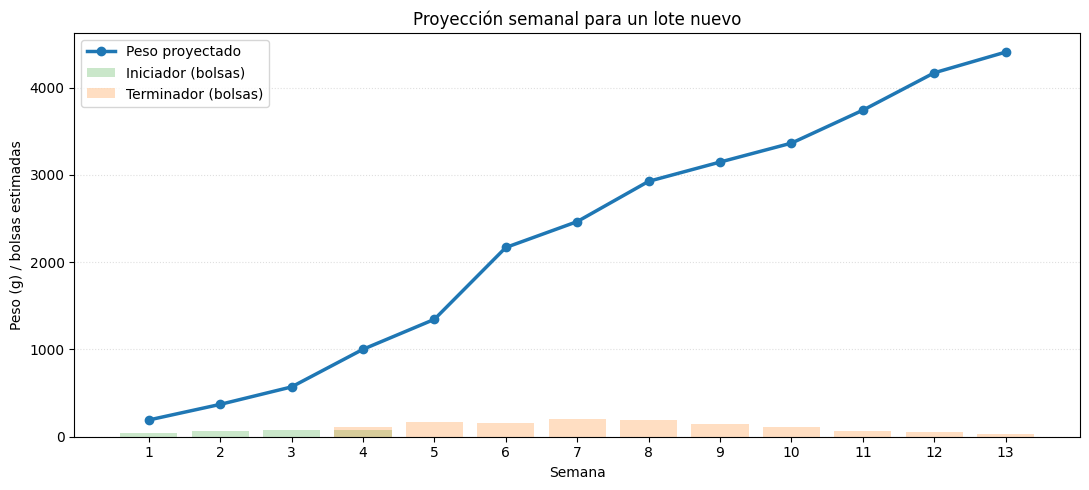

In [12]:
plt.figure(figsize=(11, 5))

plt.plot(prediccion['Semana'], prediccion['Peso_gr'], 'o-', color='#1f77b4', linewidth=2.5, label='Peso proyectado')
plt.bar(prediccion['Semana'], prediccion['Iniciador_bolsas'], color='#2ca02c', alpha=0.25, label='Iniciador (bolsas)')
plt.bar(prediccion['Semana'], prediccion['Terminador_bolsas'], color='#ff7f0e', alpha=0.25, label='Terminador (bolsas)')

plt.xlabel('Semana')
plt.ylabel('Peso (g) / bolsas estimadas')
plt.title('Proyección semanal para un lote nuevo')
plt.xticks(prediccion['Semana'])
plt.grid(True, axis='y', linestyle=':', alpha=0.4)
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()


**Interpretación de la proyección semanal para un lote nuevo**

- **Línea azul (Peso proyectado):** Representa la curva de crecimiento estimada en gramos para un lote nuevo durante las 13 semanas de producción, asumiendo condiciones estándar basadas en los promedios históricos.
- **Barras verdes (Iniciador - bolsas):** Muestra el consumo semanal estimado de alimento iniciador en bolsas (calculado típicamente para las primeras 4 semanas).
- **Barras naranjas (Terminador - bolsas):** Muestra el consumo semanal estimado de alimento terminador en bolsas (estimado a partir de la semana 4 en adelante).
- **Utilidad práctica:** Unifica la proyección de crecimiento biológico con la planificación logística. Ayuda a anticipar los momentos de mayor demanda de alimento, programar las compras de bolsas y estimar la fecha y peso comercial de salida del lote de manera anticipada.


# Lectura final de real vs predicho

Estos gráficos no buscan mostrar una predicción futura todavía, sino verificar si el modelo logra reconstruir el comportamiento de los lotes históricos. Cuando las líneas real y predicha se mantienen cerca, el modelo está capturando bien el patrón de crecimiento. Cuando se separan, conviene revisar si hubo algún evento productivo no registrado en los datos, como estrés térmico, cambios de alimento, enfermedad, densidad, ventilación o manejo.


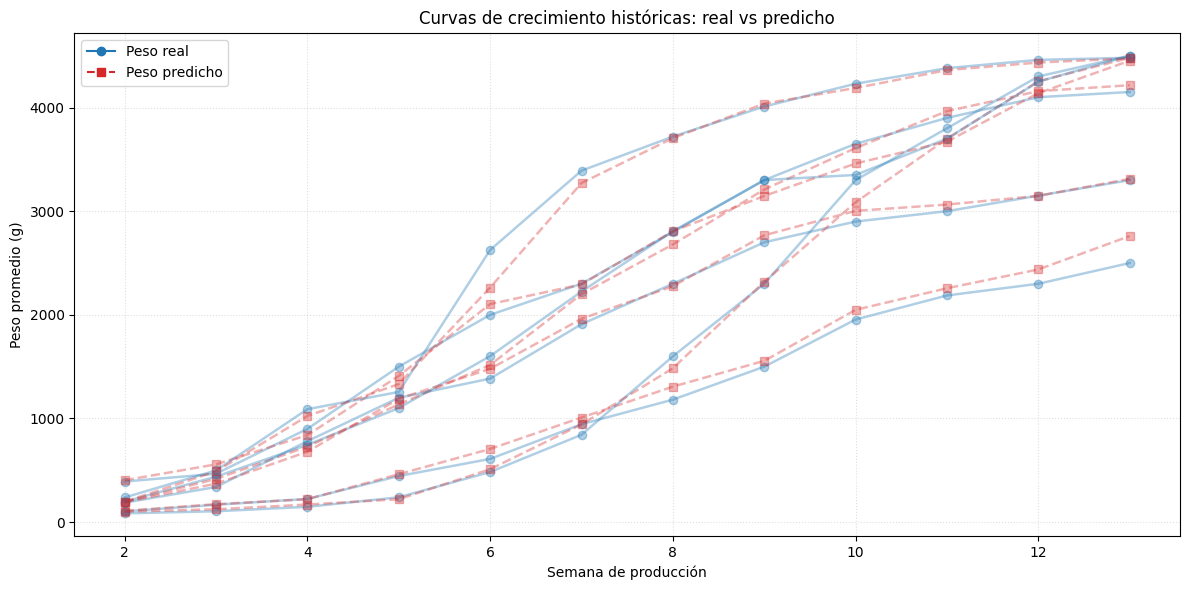

In [13]:
plt.figure(figsize=(12, 6))

color_real = '#1f77b4'
color_pred = '#d62728'

for lote in sorted(df_modelo['Lote'].unique()):
    subset = df_modelo[df_modelo['Lote'] == lote]
    plt.plot(subset['Semana_prod'], subset['Peso_gr'], 'o-', color=color_real, linewidth=1.8, alpha=0.35)
    plt.plot(subset['Semana_prod'], subset['Peso_pred'], 's--', color=color_pred, linewidth=1.8, alpha=0.35)

real_line = plt.Line2D([0], [0], color=color_real, marker='o', linestyle='-', label='Peso real')
pred_line = plt.Line2D([0], [0], color=color_pred, marker='s', linestyle='--', label='Peso predicho')
plt.legend(handles=[real_line, pred_line], loc='upper left')

plt.xlabel('Semana de producción')
plt.ylabel('Peso promedio (g)')
plt.title('Curvas de crecimiento históricas: real vs predicho')
plt.grid(True, linestyle=':', alpha=0.4)
plt.tight_layout()
plt.show()


# Resultados de consumo: reales vs predichos

En estos gráficos, cada punto compara bolsas reales contra bolsas estimadas. La línea punteada representa el escenario ideal: predicción igual al dato real. Puntos por encima de la línea indican sobreestimación; puntos por debajo indican subestimación.

Como el alimento depende de decisiones de manejo y disponibilidad, estos modelos son útiles para orientación y planificación, pero deberían complementarse con información de fórmula, temperatura, densidad, edad exacta y objetivo comercial del lote.


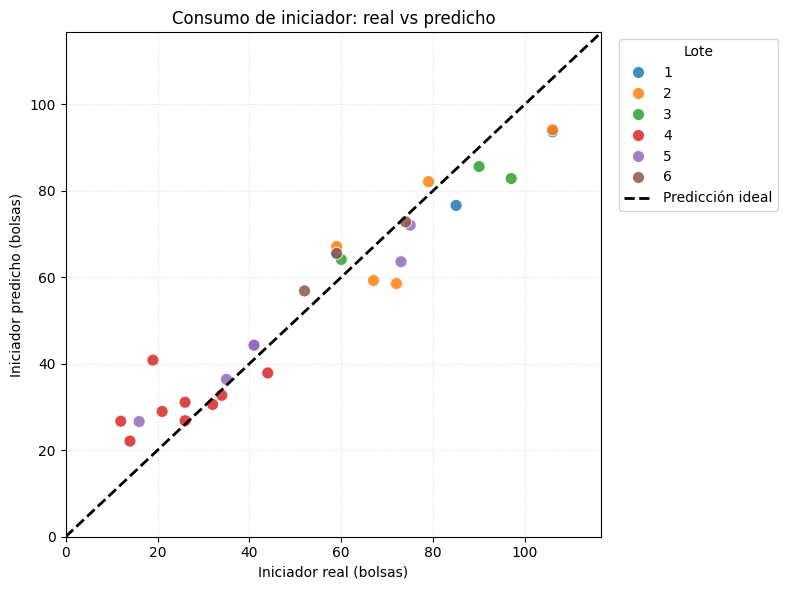

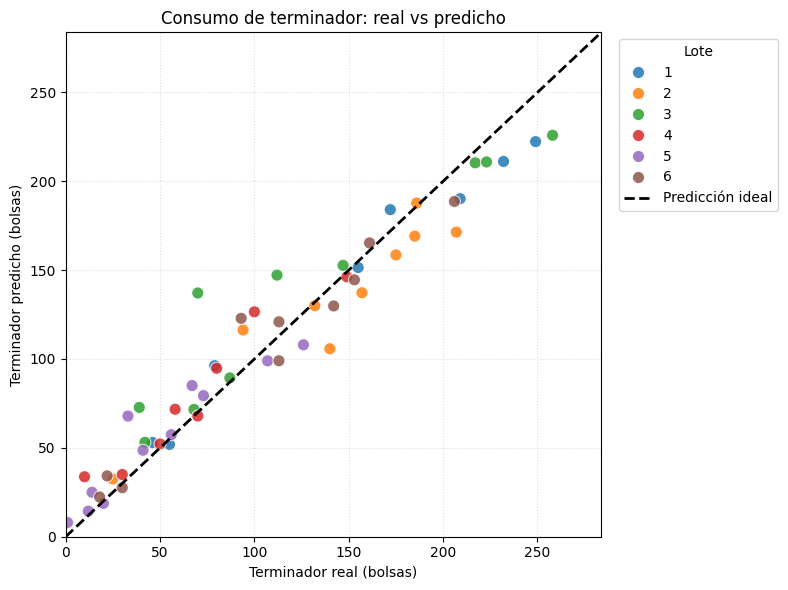

In [14]:
# Iniciador

df_iniciador = df_modelo[df_modelo['Iniciador_bolsas'] > 0].copy()
df_iniciador['Ini_pred'] = rf_ini.predict(df_iniciador[features_cons])

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_iniciador, x='Iniciador_bolsas', y='Ini_pred', hue='Lote', palette='tab10', s=75, alpha=0.85)
lim_ini = max(df_iniciador['Iniciador_bolsas'].max(), df_iniciador['Ini_pred'].max()) * 1.1
plt.plot([0, lim_ini], [0, lim_ini], color='black', linestyle='--', linewidth=2, label='Predicción ideal')
plt.xlim(0, lim_ini)
plt.ylim(0, lim_ini)
plt.xlabel('Iniciador real (bolsas)')
plt.ylabel('Iniciador predicho (bolsas)')
plt.title('Consumo de iniciador: real vs predicho')
plt.grid(True, linestyle=':', alpha=0.4)
plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1), title='Lote')
plt.tight_layout()
plt.show()

# Terminador

df_terminador = df_modelo[df_modelo['Terminador_bolsas'] > 0].copy()
df_terminador['Ter_pred'] = rf_ter.predict(df_terminador[features_cons])

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_terminador, x='Terminador_bolsas', y='Ter_pred', hue='Lote', palette='tab10', s=75, alpha=0.85)
lim_ter = max(df_terminador['Terminador_bolsas'].max(), df_terminador['Ter_pred'].max()) * 1.1
plt.plot([0, lim_ter], [0, lim_ter], color='black', linestyle='--', linewidth=2, label='Predicción ideal')
plt.xlim(0, lim_ter)
plt.ylim(0, lim_ter)
plt.xlabel('Terminador real (bolsas)')
plt.ylabel('Terminador predicho (bolsas)')
plt.title('Consumo de terminador: real vs predicho')
plt.grid(True, linestyle=':', alpha=0.4)
plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1), title='Lote')
plt.tight_layout()
plt.show()
